# B3 — Multi-Terrain Nested Consistency


        B3는 B2에서 고정한 동일한 비교 절차를 single hill과 goal-in-valley에
        적용한다. 새로운 outer optimum을 찾는 단계가 아니라, **같은 solver
        family가 다른 terrain에서도 어떻게 달라지는지** 보는 확장 실험이다.

In [1]:
from pathlib import Path
import json
from html import escape
import subprocess
import sys
from IPython.display import display, Markdown, Image, HTML, FileLink

def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "p1b_4D").is_dir() and (candidate / "p1b_roadmap_0729.md").exists():
            return candidate
    raise RuntimeError("glider_hybrid_control repository root를 찾지 못했습니다.")

ROOT = locate_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
STAGE = "B3"
STATUS = "COMPLETED"

def run_module(module, *arguments, timeout=None):
    command = [sys.executable, "-m", module, *map(str, arguments)]
    completed = subprocess.run(
        command, cwd=ROOT, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f"{module} 실행 실패: exit={completed.returncode}")
    return completed.stdout

def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"결과 파일이 없습니다: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def show_png(path, width=1050):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"> ⚠️ 그림이 없습니다: `{path}`"))

def display_table(rows, columns=None):
    if isinstance(rows, dict):
        rows = [rows]
    rows = list(rows)
    if columns is None:
        columns = []
        for row in rows:
            for key in row:
                if key not in columns:
                    columns.append(key)
    if not rows:
        display(Markdown("_(표시할 행이 없습니다.)_"))
        return
    def cell(value):
        if isinstance(value, float):
            value = f"{value:.8g}"
        elif isinstance(value, (dict, list, tuple)):
            value = json.dumps(value, ensure_ascii=False)
        return escape(str(value))
    header = "".join(f"<th>{cell(name)}</th>" for name in columns)
    body = "".join(
        "<tr>" + "".join(f"<td>{cell(row.get(name, ''))}</td>" for name in columns) + "</tr>"
        for row in rows
    )
    display(HTML(
        "<div style='overflow-x:auto'><table>"
        f"<thead><tr>{header}</tr></thead><tbody>{body}</tbody></table></div>"
    ))

display(Markdown(f"**{STAGE} 상태:** `{STATUS}`  \nRepository: `{ROOT}`"))

**B3 상태:** `COMPLETED`  
Repository: `C:\Users\jeffe\Desktop\git\glider_hybrid_control`

In [2]:
RERUN = False  # True이면 36-case 전체를 다시 계산하므로 오래 걸립니다.
RESULT_PATH = RESULTS / "direction_b" / "b3_multiterrain_nested_consistency.json"
FIGURE_DIR = RESULTS / "direction_b" / "figures"
if RERUN:
    run_module(
        "p1b_4D.experiment_b3_multiterrain_nested_consistency",
        "--output", RESULT_PATH,
    )
result = load_json(RESULT_PATH)
display(Markdown(
    f"**상태:** `{result['status']}` · cases={result['case_count']} · "
    f"feasible={result['feasible_case_count']} · "
    f"common evaluator={result['global_common_evaluator_sample_count']}"
))

**상태:** `complete` · cases=36 · feasible=30 · common evaluator=1025

In [3]:
rows = []
for case in result["cases"]:
    if (
        case["action_family"] == "enriched"
        and case["speed_family"] == "V5"
        and case["planning_quadrature_count"] == 9
    ):
        rows.append({
            "terrain": case["terrain_name"],
            "sensor": case["sensor_name"],
            "level": f"L{case['level']}",
            "status": case["status"],
            "HF attacker objective": (
                case.get("selected_high_fidelity", {}).get("attacker_objective")
            ),
            "switch z": case.get("planning", {}).get("switching_point", [None])[0],
        })
display_table(rows)
ranking_rows = []
for terrain, analysis in result["analysis"].items():
    ranking_rows.append({
        "terrain": terrain,
        "ranking sign stable": analysis["ranking_sign_stable"],
        "ranking resolved": analysis["ranking_diagnostically_resolved"],
        "production speed": analysis["production_speed_family_if_terrain_only"],
        "planning quadrature": analysis["production_planning_quadrature_count_if_terrain_only"],
    })
display_table(ranking_rows)

terrain,sensor,level,status,HF attacker objective,switch z
single_hill,coverage,L0,feasible,0.67438896,1134.375
single_hill,coverage,L1,feasible,0.54470702,1100
single_hill,coverage,L2,feasible,0.53553959,773.4375
single_hill,stackelberg,L0,feasible,0.67446558,1134.375
single_hill,stackelberg,L1,feasible,0.54471813,1100
single_hill,stackelberg,L2,feasible,0.53554016,773.4375
goal_in_valley,coverage,L0,feasible,0.91399192,827.58621
goal_in_valley,coverage,L1,feasible,0.36920057,827.58621
goal_in_valley,coverage,L2,feasible,0.32363861,818.96552
goal_in_valley,stackelberg,L0,feasible,0.90324638,827.58621


terrain,ranking sign stable,ranking resolved,production speed,planning quadrature
goal_in_valley,True,False,V5,9
single_hill,True,False,V5,9


2026-07-30 09:44:57,072 | INFO | stackelberg | phase=Phase 1: Configuration status=started


2026-07-30 09:44:57,075 | WARNING | stackelberg | phase=Phase 1: Configuration warning=Vehicle segment_length is deferred to the future transcription contract instead of fabricating a Phase 1 value


2026-07-30 09:44:57,075 | INFO | stackelberg | phase=Phase 1: Configuration status=success elapsed_seconds=0.002488


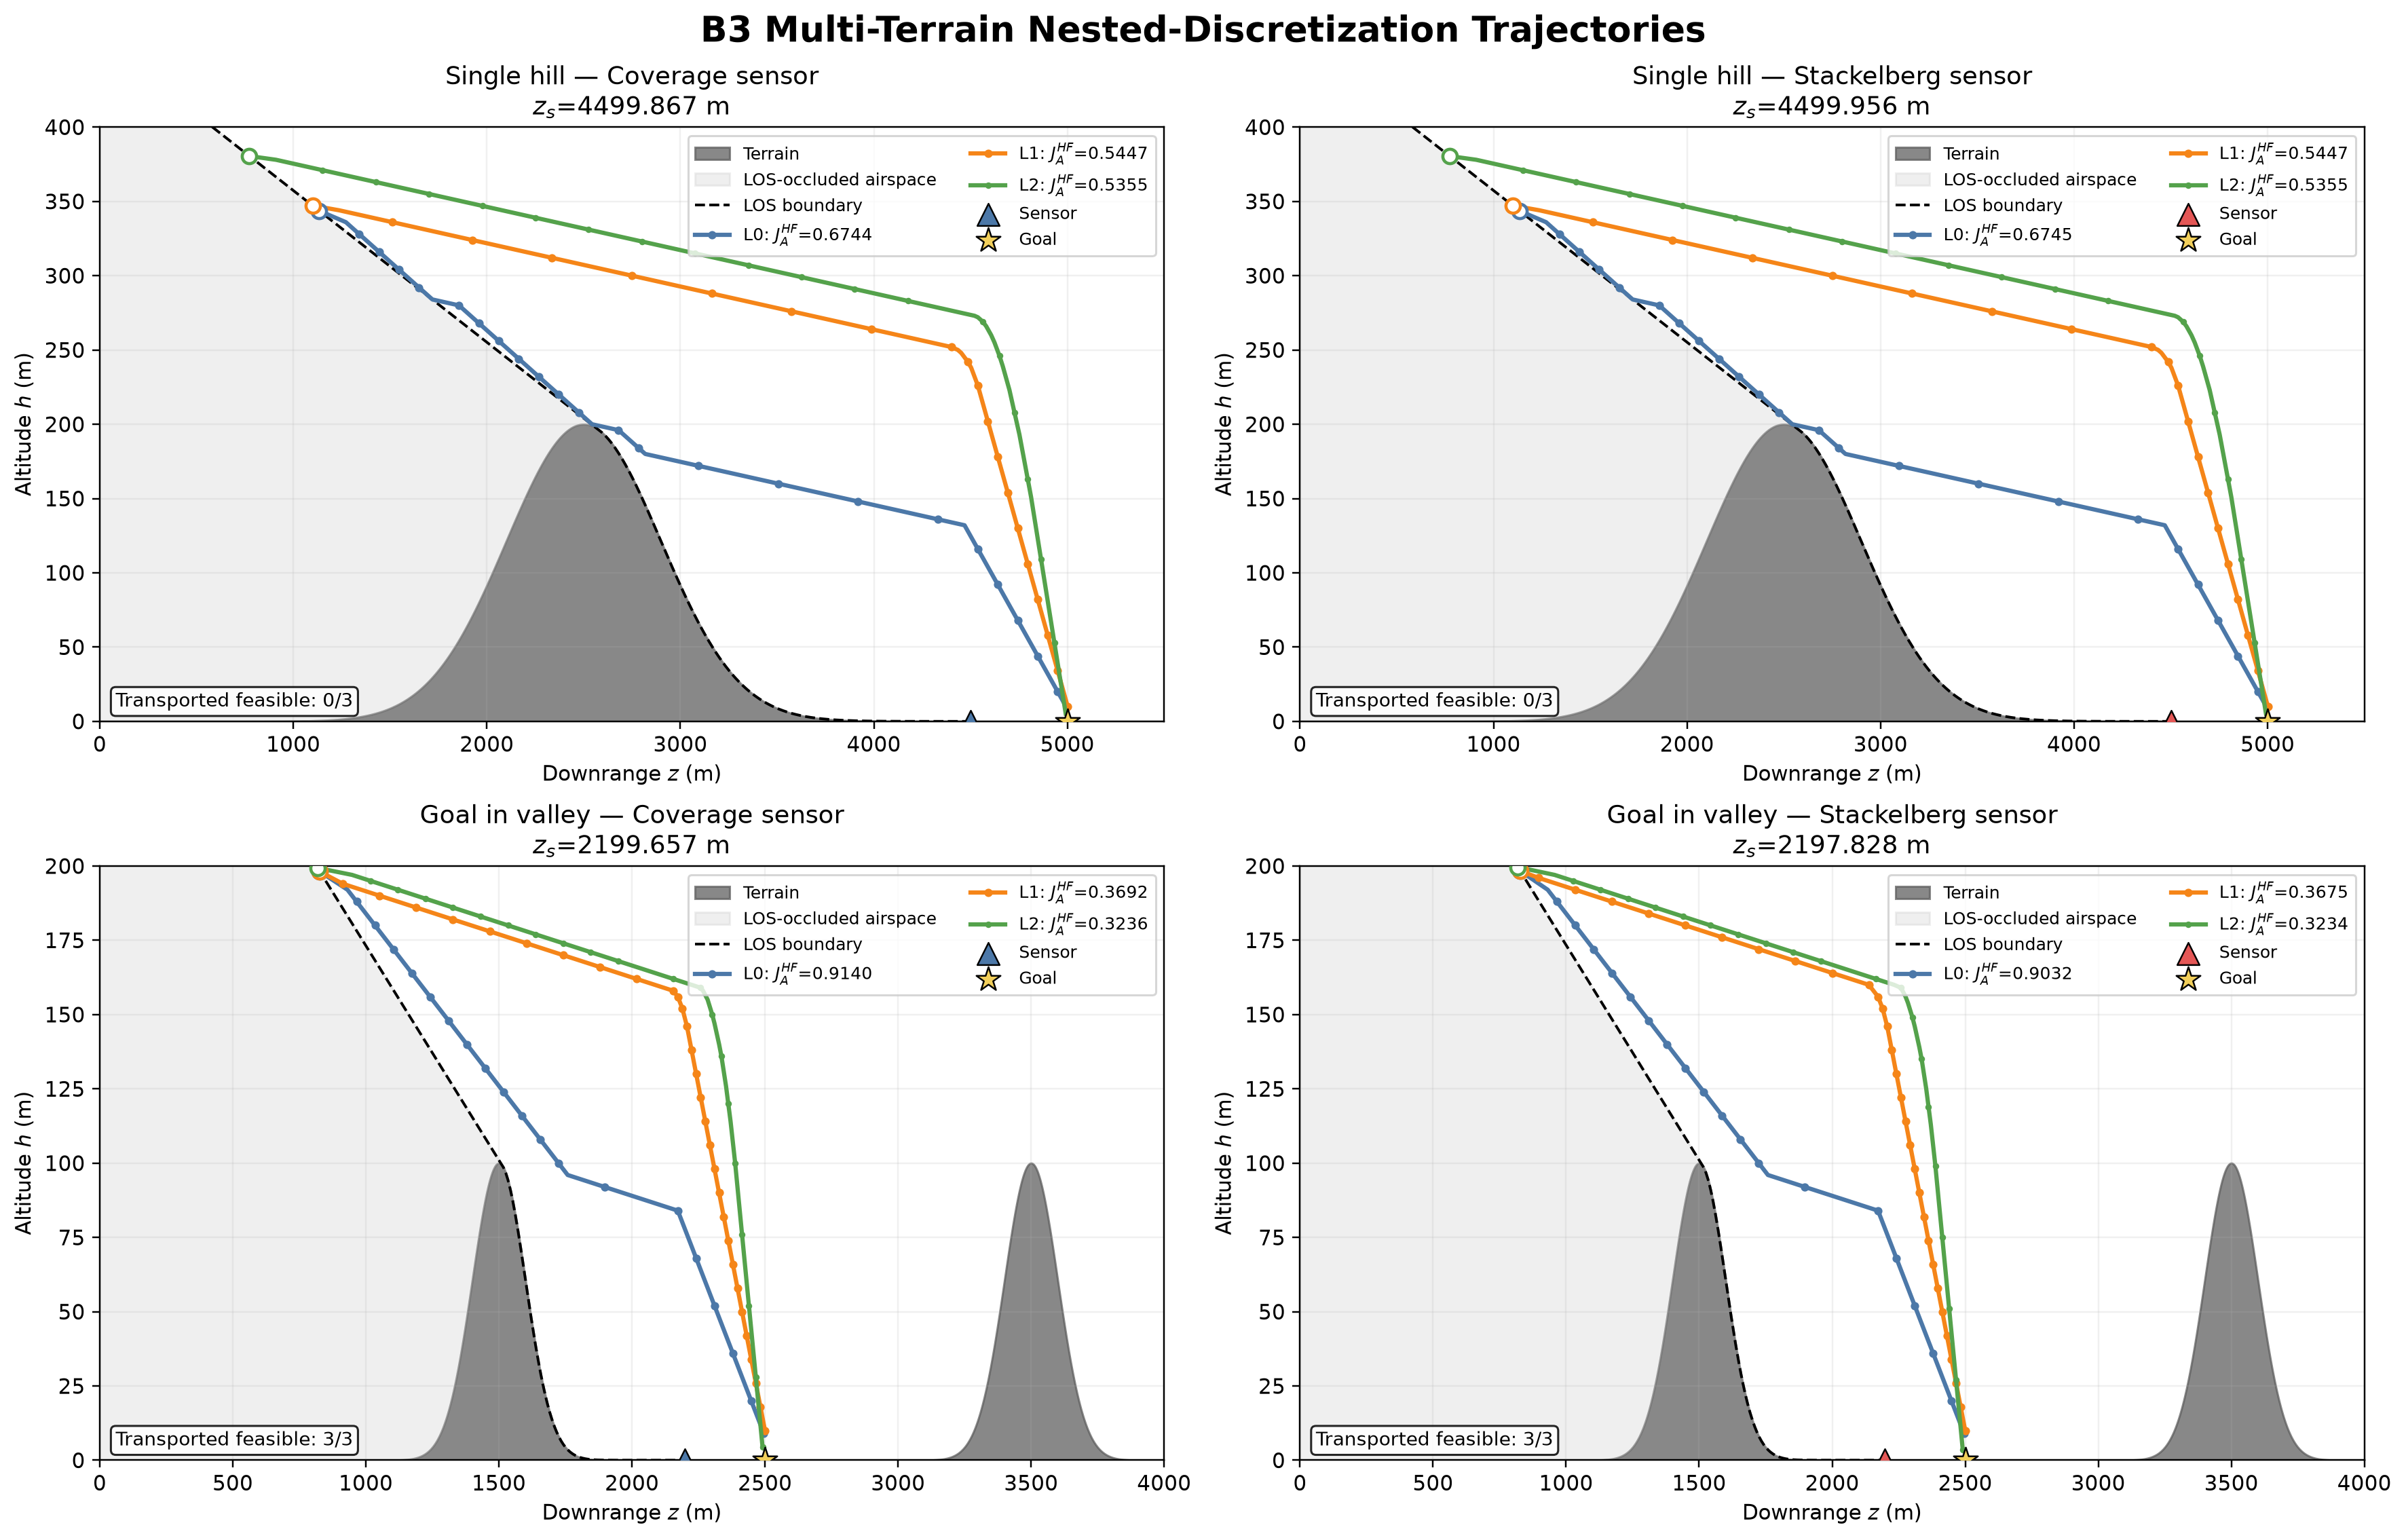

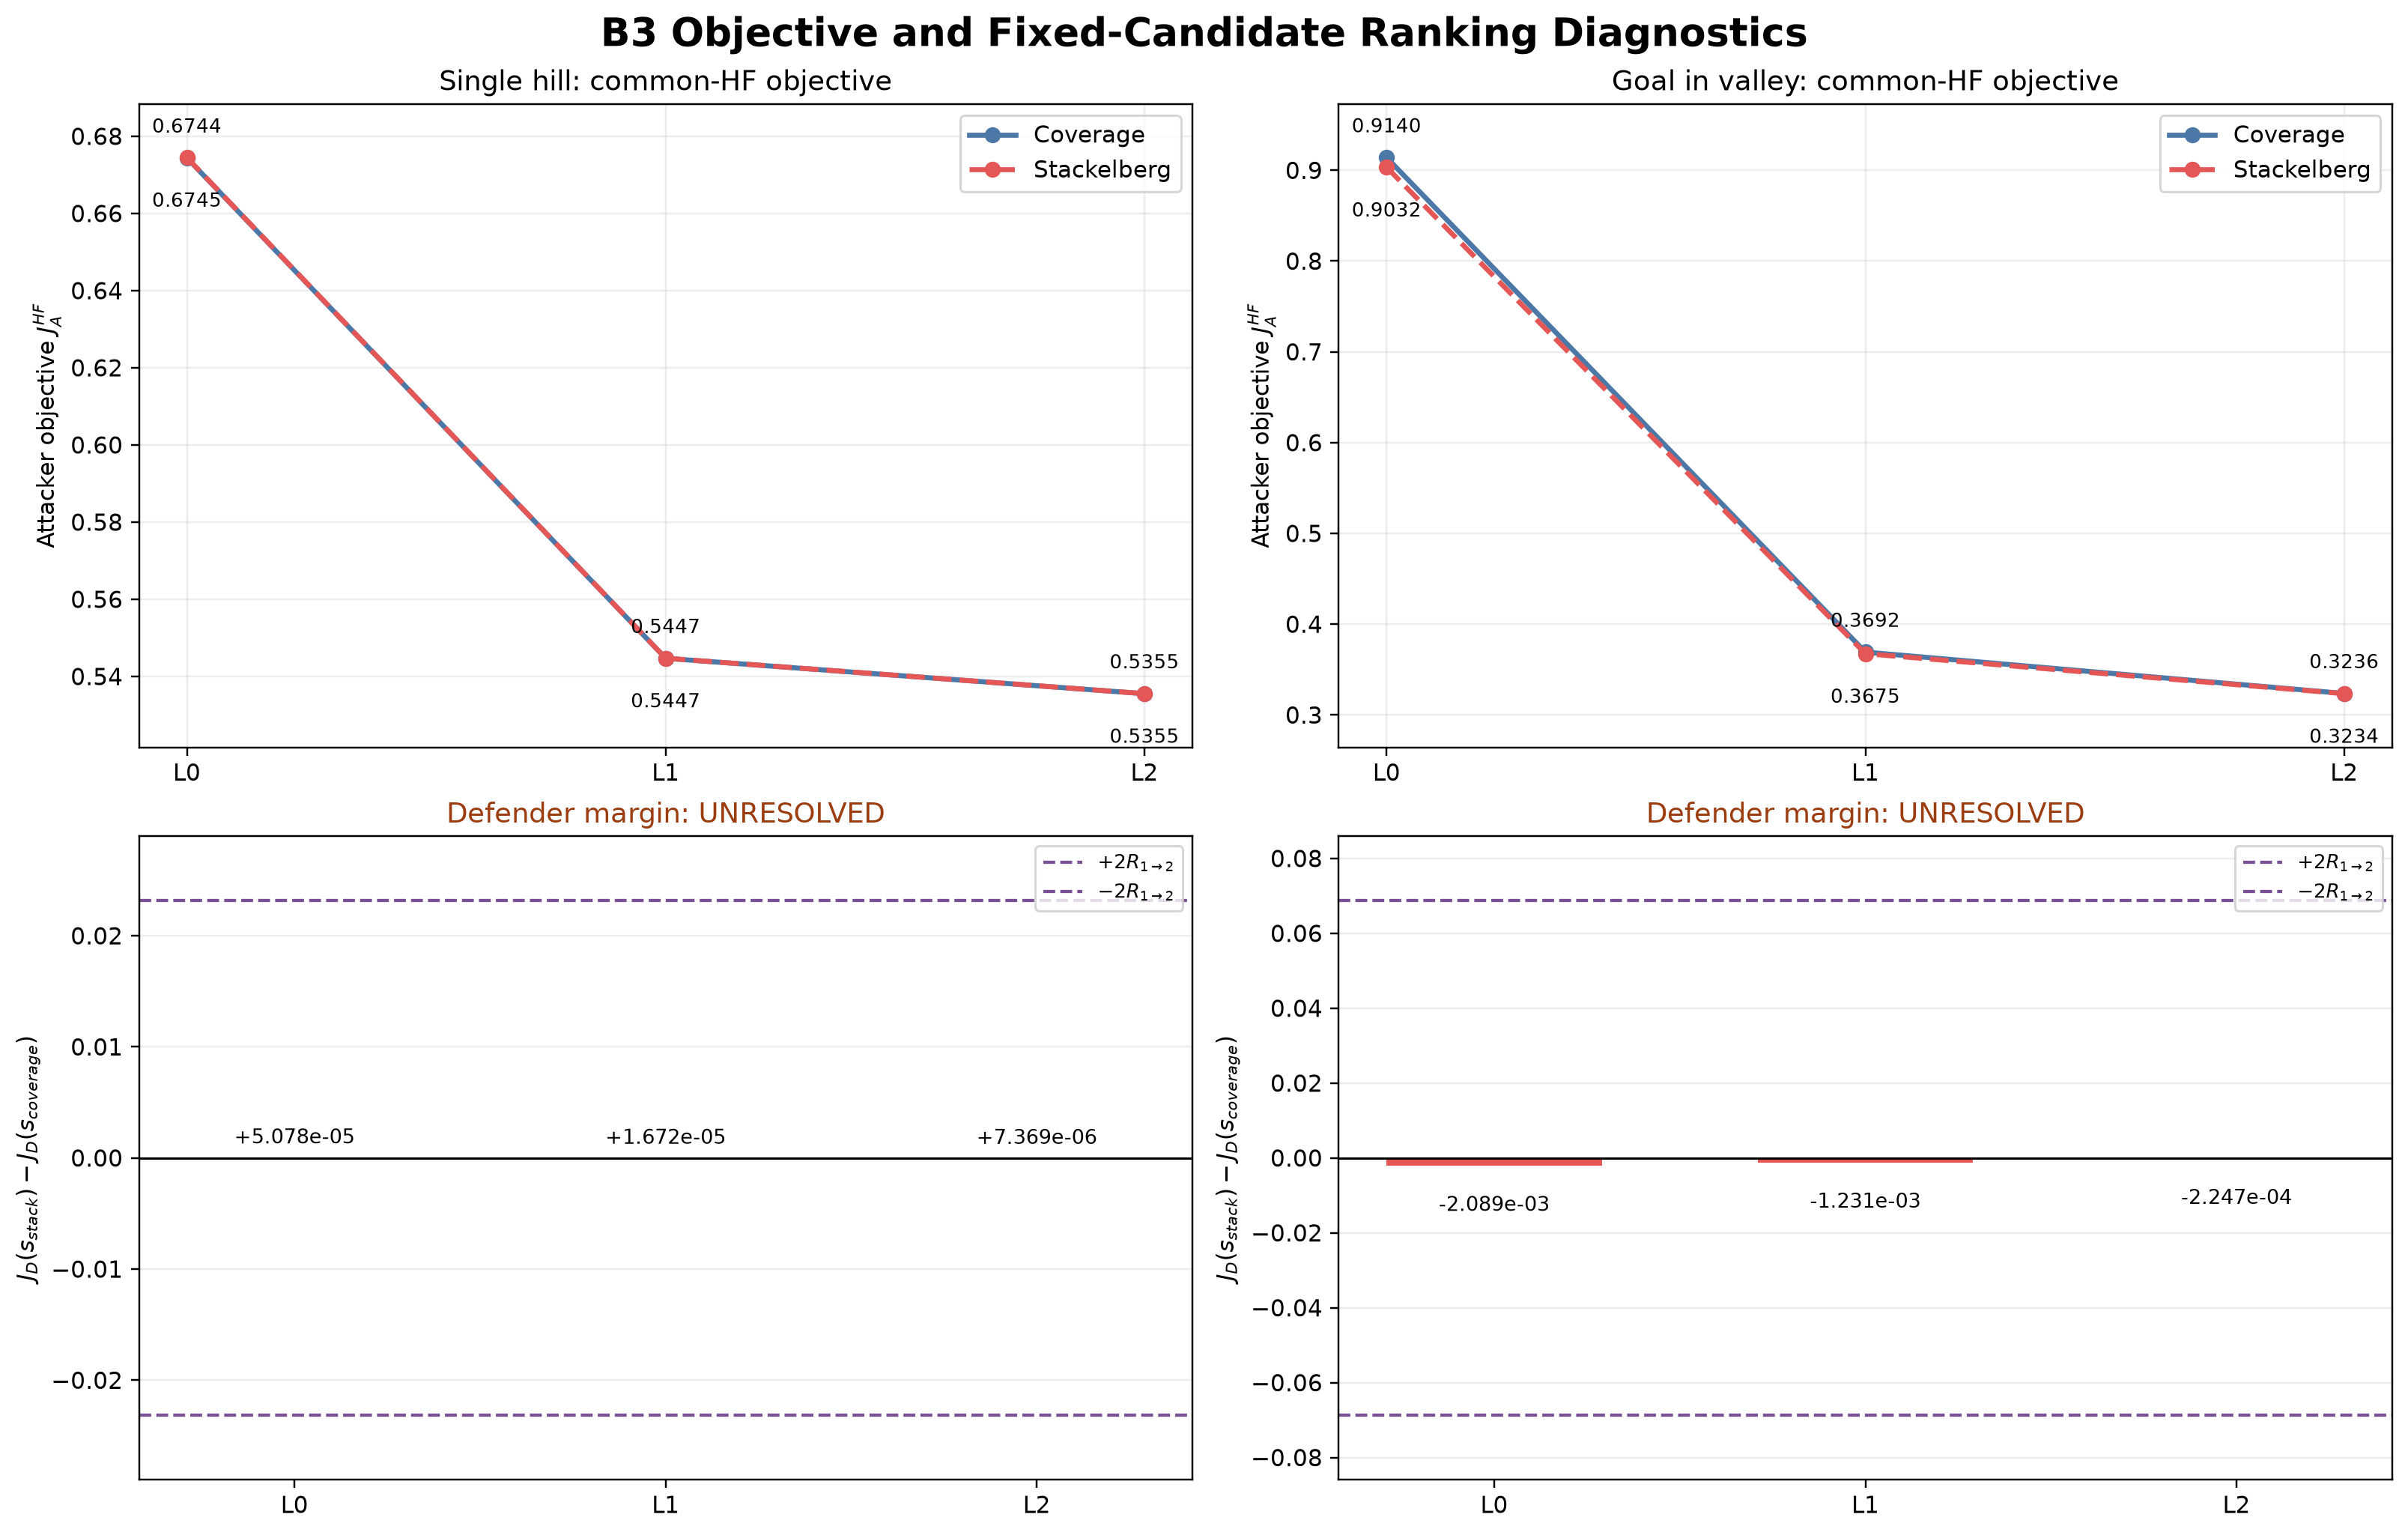

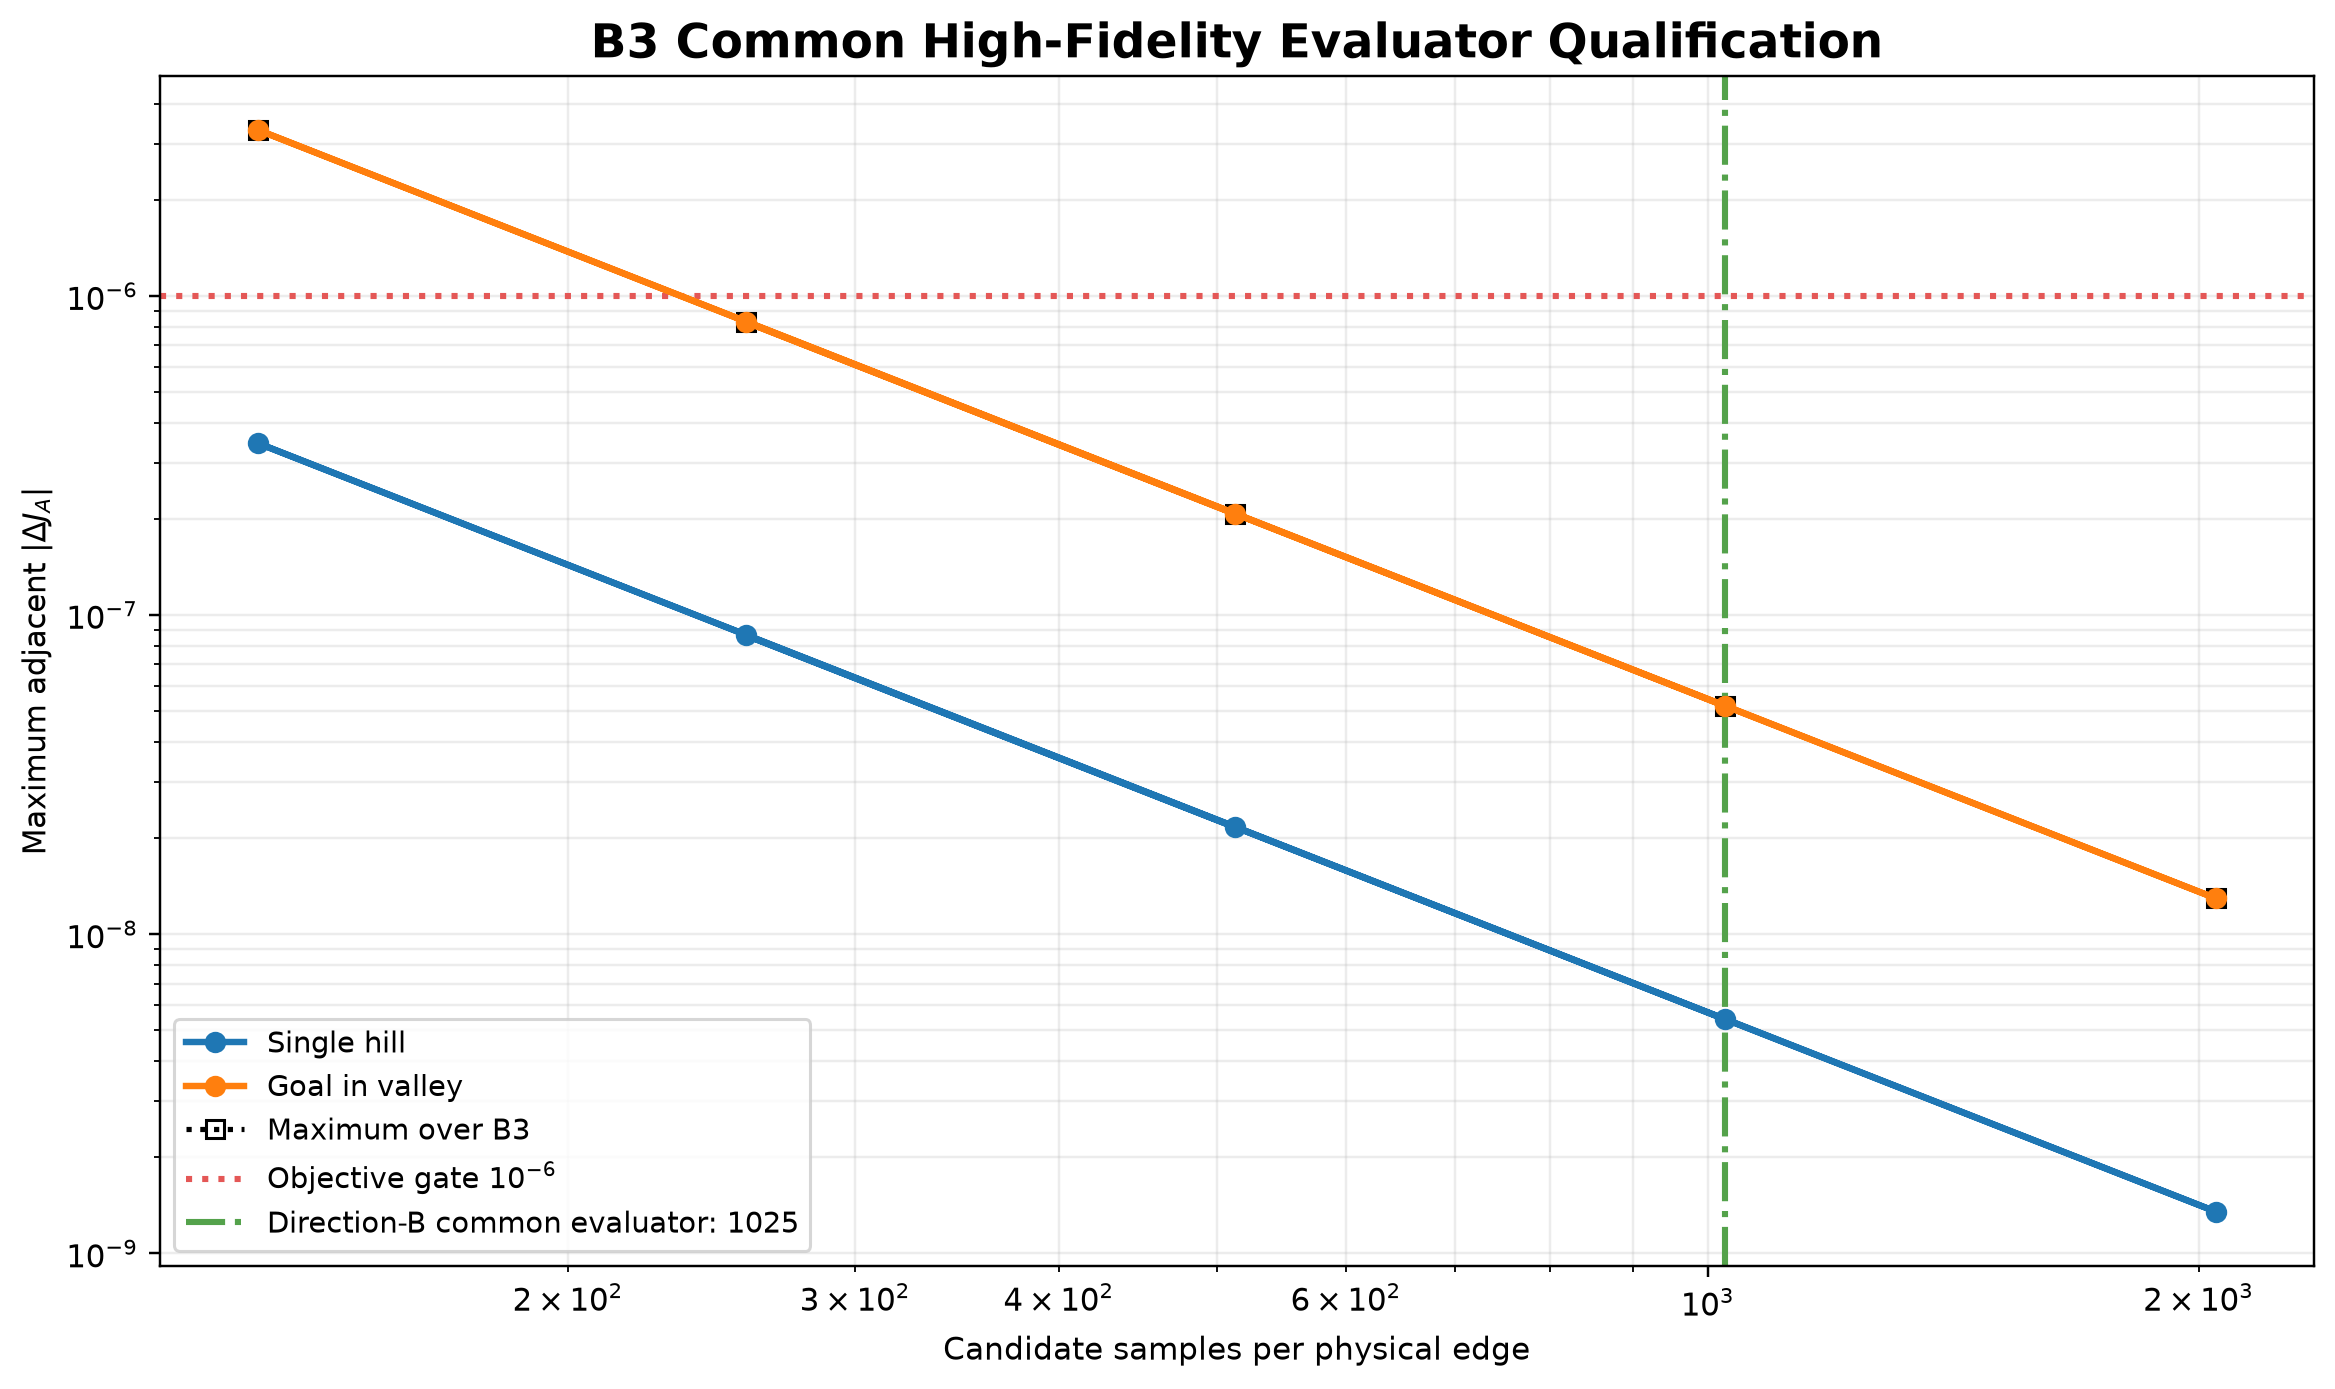

In [4]:
from p1b_4D.visualize_b3_multiterrain_nested_consistency import create_b3_figures
figure_paths = create_b3_figures(RESULT_PATH, FIGURE_DIR, ROOT)
for figure_path in figure_paths:
    show_png(figure_path)

## 직관적 결론

동일한 action family라도 terrain/goal 구조에 따라 feasibility와
ranking sensitivity가 달라진다. 특히 single-hill과 valley의 두
고정 sensor 후보 순위는 resolution noise보다 작으므로, 이를
연속-game의 확정적 순위로 해석하지 않는다.